# Project: HR Employee Attrition Analysis

In [571]:
import pandas as pd
import numpy as np

In [572]:
# Import Data
df= pd.read_excel("HR-Employee-Attrition.xlsx")

In [573]:
#Display the data
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Check the dataset

In [574]:
df.shape

(1470, 35)

In [575]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [576]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [577]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [578]:
df.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


### Check for missing data

In [579]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [580]:
# Observation: No missing values were found in the dataset.

### Check for duplicates

In [581]:
df.duplicated().sum()

np.int64(0)

In [582]:
# Observation: No duplicate records were found.

### Check Unique values

In [583]:
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [584]:
# Observation: We have found 3 constant columns. That means only one unique value for these columns. 
# They do not provide any meaningful information for analysis so we need to remove these columns.
# EmployeeCount, Over18 and StandardHours

In [585]:
# Keeping the columns which has nunique value>1.
df=df.loc[:,df.nunique()>1]

In [586]:
# Also there's no use of EmployeeNumber number column.
# Drop redundant or zero-variance columns

df=df.drop(columns='EmployeeNumber')

In [587]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [588]:
# Now we have 31 columns.

In [589]:
# To find unique values in each categorical columns.

for col in df.select_dtypes(include='object').columns:
    print(col)
    print(df[col].unique())
    print('\n')

Attrition
['Yes' 'No']


BusinessTravel
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']


Department
['Sales' 'Research & Development' 'Human Resources']


EducationField
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']


Gender
['Female' 'Male']


JobRole
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']


MaritalStatus
['Single' 'Married' 'Divorced']


OverTime
['Yes' 'No']




In [590]:
# We can clean text values. If there's any extra spaces.

df['Department']=df['Department'].str.strip()
df['Department']

0                        Sales
1       Research & Development
2       Research & Development
3       Research & Development
4       Research & Development
                 ...          
1465    Research & Development
1466    Research & Development
1467    Research & Development
1468                     Sales
1469    Research & Development
Name: Department, Length: 1470, dtype: object

### Check Outliers

In [591]:
# Select continuous numerical columns likely to have outliers
outlier_features = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion']

for col in outlier_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"(Column '{col}': {len(outliers_count)} outliers)")


(Column 'MonthlyIncome': 114 outliers)
(Column 'TotalWorkingYears': 63 outliers)
(Column 'YearsAtCompany': 104 outliers)
(Column 'YearsSinceLastPromotion': 107 outliers)


In [592]:
# Count employees who stayed and left
attrition_counts = df["Attrition"].value_counts()

print(attrition_counts)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


### Overall Attrition

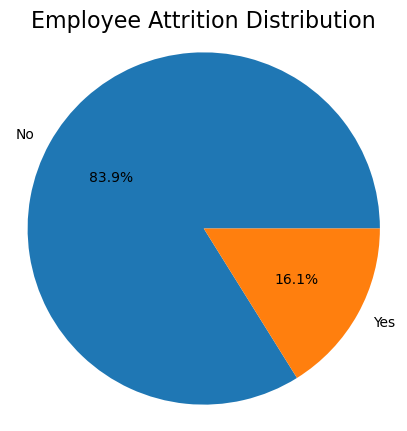

In [593]:
# Target Variable Distribution
# Before looking at relationships, check the exact balance of your Attrition column. This confirms the data imbalance and sets your baseline.
# What it tells you: The percentage of employees who left vs. those who stayed.

plt.figure(figsize=(5, 5))

plt.pie(attrition_counts, labels=attrition_counts.index, autopct="%1.1f%%")

plt.title("Employee Attrition Distribution", fontsize=16)
plt.axis("equal")   # Makes the pie chart circular

plt.show()

### Attrition by Department

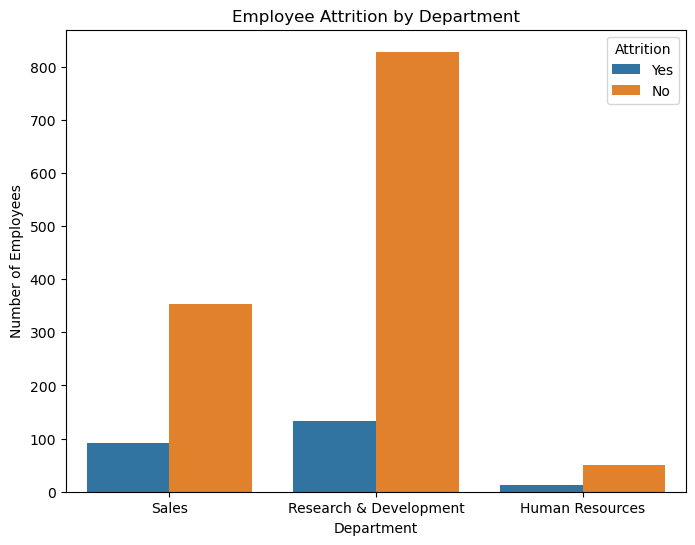

In [594]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x="Department",
    hue="Attrition",
)

plt.title("Employee Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.show()

### Monthly Income vs Attrition

C:\Users\Panna Chetry\AppData\Local\Temp\ipykernel_21092\3825557417.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition',y='MonthlyIncome', data=df, palette='bright')


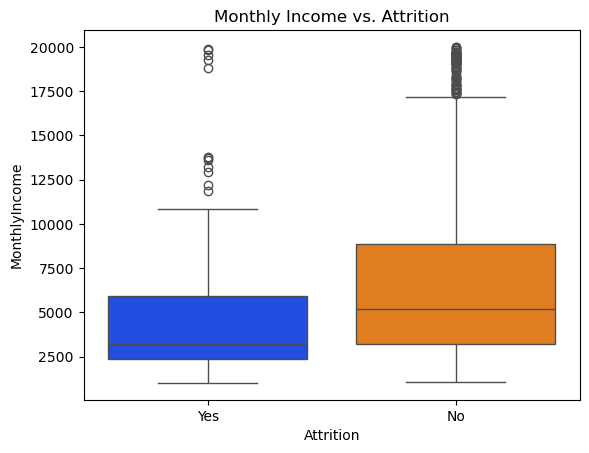

In [595]:
sns.boxplot(x='Attrition',y='MonthlyIncome', data=df, palette='bright')
plt.title('Monthly Income vs. Attrition')
plt.ylabel('MonthlyIncome')
plt.show()

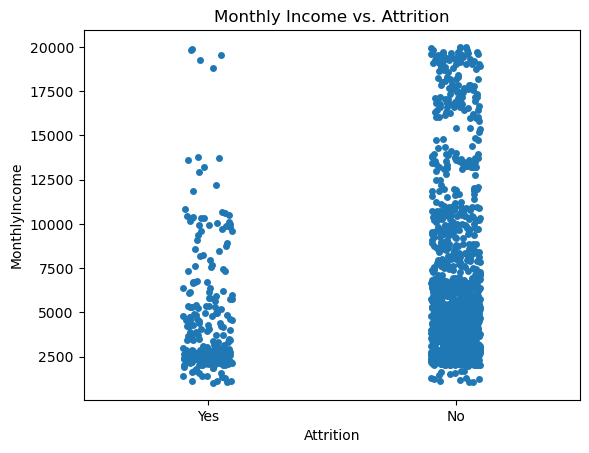

In [596]:
sns.stripplot(x='Attrition',y='MonthlyIncome', data=df)
plt.title('Monthly Income vs. Attrition')
plt.show()

C:\Users\Panna Chetry\AppData\Local\Temp\ipykernel_21092\624446516.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='YearsAtCompany',data=df, palette='bright')


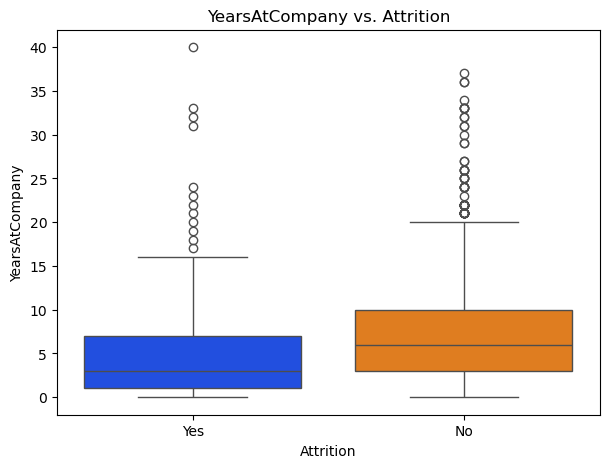

In [597]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Attrition', y='YearsAtCompany',data=df, palette='bright')
plt.title('YearsAtCompany vs. Attrition')
plt.xlabel('Attrition')
plt.ylabel('YearsAtCompany')
plt.show()

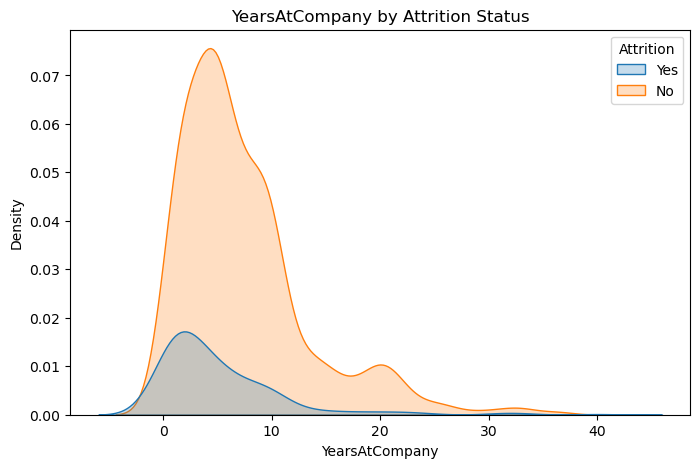

In [598]:
#YearsAtCompany comparison using a KDE (Density) Plot
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='YearsAtCompany', hue='Attrition',fill=True)
plt.title('YearsAtCompany by Attrition Status')
plt.xlabel('YearsAtCompany')
plt.ylabel('Density')
plt.show()

### Overtime vs Attrition

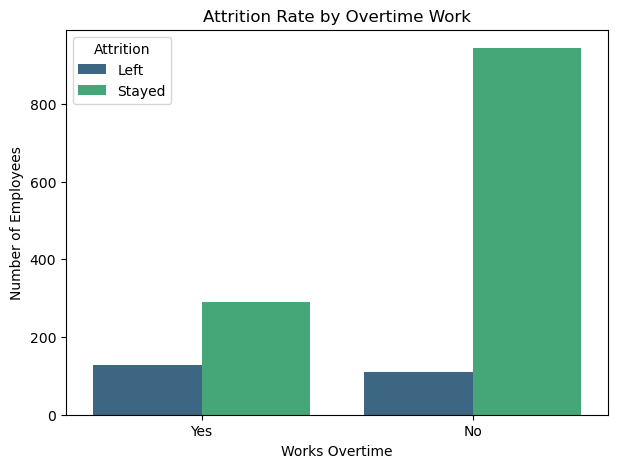

In [599]:
# Check Attrition by OverTime Status
plt.figure(figsize=(7, 5))
sns.countplot(x='OverTime', hue='Attrition', data=df, palette='viridis')
plt.title('Attrition Rate by Overtime Work')
plt.xlabel('Works Overtime')
plt.ylabel('Number of Employees')
plt.legend(title='Attrition', labels=['Left', 'Stayed'])
plt.show()

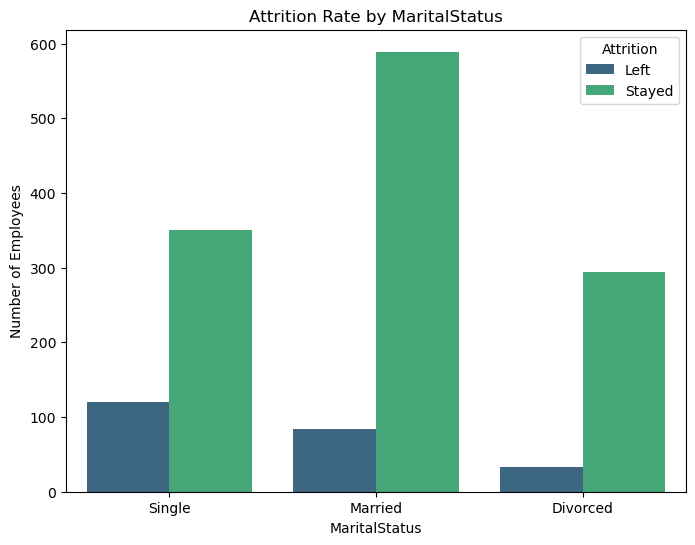

In [600]:
# Check Attrition by MaritalStatus
plt.figure(figsize=(8, 6))
sns.countplot(x='MaritalStatus', hue='Attrition', data=df, palette='viridis')
plt.title('Attrition Rate by MaritalStatus')
plt.xlabel('MaritalStatus')
plt.ylabel('Number of Employees')
plt.legend(title='Attrition', labels=['Left', 'Stayed'])
plt.show()

### Attrition by JobRole

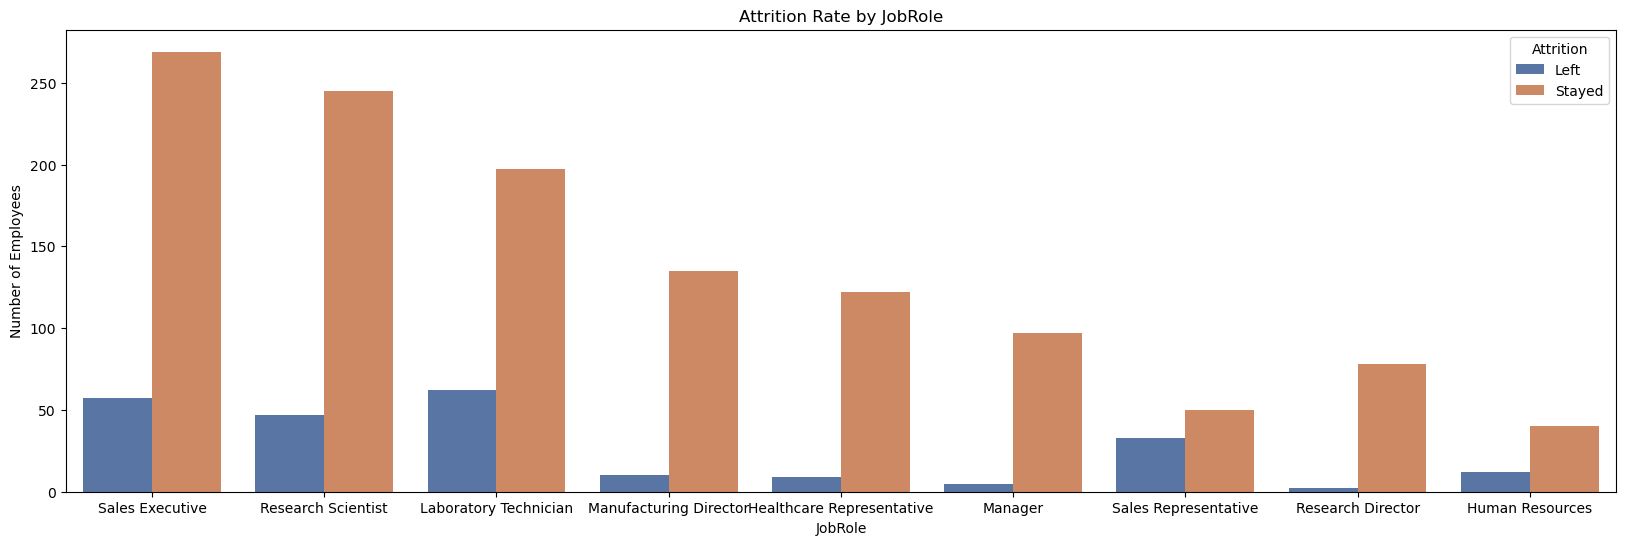

In [601]:
# Check Attrition by JobRole
plt.figure(figsize=(20, 6))
sns.countplot(x='JobRole', hue='Attrition', data=df, palette='deep')
plt.title('Attrition Rate by JobRole')
plt.xlabel('JobRole')
plt.ylabel('Number of Employees')
plt.legend(title='Attrition', labels=['Left', 'Stayed'])
plt.show()

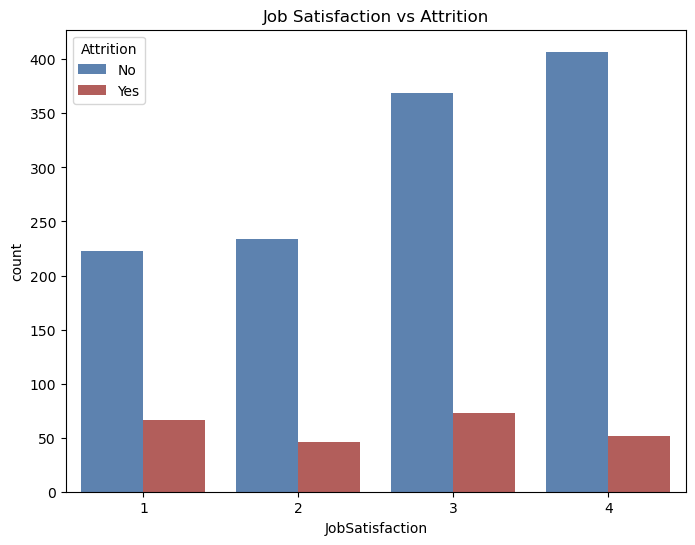

In [602]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x="JobSatisfaction",
    hue="Attrition",
    palette=["#4F81BD","#C0504D"]
)

plt.title("Job Satisfaction vs Attrition")
plt.show()

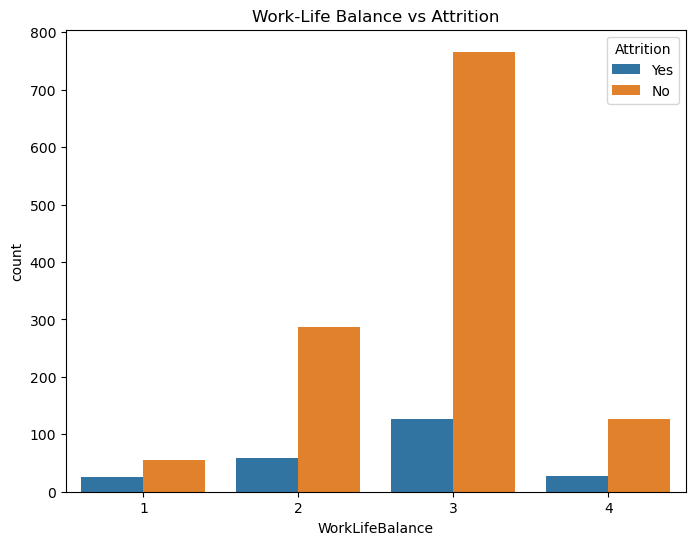

In [603]:
plt.figure(figsize=(8,6))

sns.countplot(data=df,
    x="WorkLifeBalance",
    hue="Attrition")

plt.title("Work-Life Balance vs Attrition")

plt.show()

### Age vs Attrition

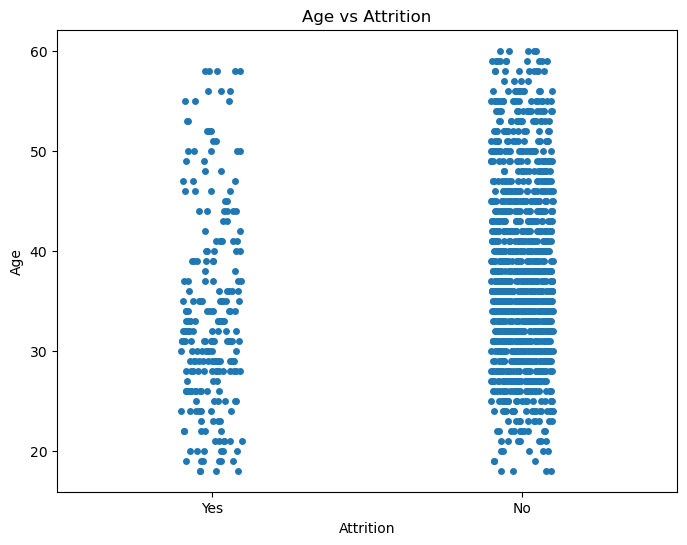

In [604]:
plt.figure(figsize=(8,6))

sns.stripplot(
    data=df, x="Attrition",
    y="Age")

plt.title("Age vs Attrition")

plt.show()

C:\Users\Panna Chetry\AppData\Local\Temp\ipykernel_21092\4030100248.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,


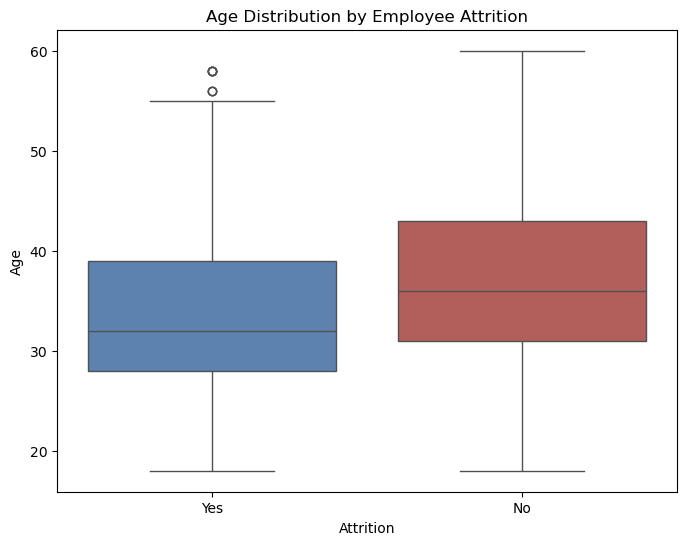

In [605]:
plt.figure(figsize=(8,6))

sns.boxplot(data=df,
    x="Attrition",
    y="Age",
    palette=["#4F81BD", "#C0504D"])

plt.title("Age Distribution by Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Age")
plt.show()

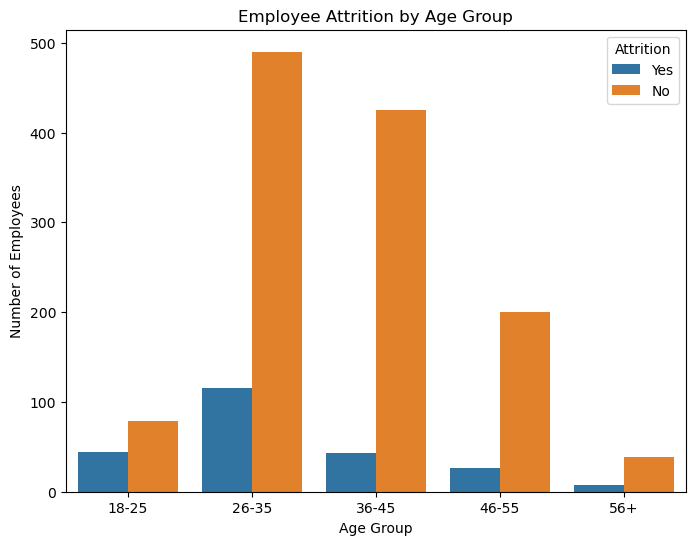

In [606]:
# Create age groups
# Define the boundaries for your age buckets
# This creates brackets: 18-25, 26-35, 36-45, 46-55, 56+
age_bins = [17, 25, 35, 45, 55, 100]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56+']

# Create the new categorical column
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)
plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x="AgeGroup",
    hue="Attrition",
)

plt.title("Employee Attrition by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")
plt.show()


In [607]:
corr = df.corr(numeric_only=True)
corr

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,0.010146,0.024287,0.029820,0.509604,-0.004892,0.497855,...,0.001904,0.053535,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,0.018355,0.023381,0.046135,0.002966,0.030571,0.007707,...,0.000473,0.007846,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,-0.016075,0.031131,0.008783,0.005303,-0.003669,-0.017014,...,0.027110,0.006557,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,-0.027128,0.016775,0.042438,0.101589,-0.011296,0.094961,...,-0.024539,-0.009118,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,1.000000,-0.049857,-0.008278,0.001212,-0.006784,-0.006259,...,-0.029548,0.007665,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,0.023381,0.031131,0.016775,-0.049857,1.000000,0.042861,-0.027853,-0.071335,-0.015794,...,-0.002172,0.001330,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,0.046135,0.008783,0.042438,-0.008278,0.042861,1.000000,-0.012630,-0.021476,-0.015271,...,-0.029071,0.034297,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.002966,0.005303,0.101589,0.001212,-0.027853,-0.012630,1.000000,-0.001944,0.950300,...,-0.021222,0.021642,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281
JobSatisfaction,-0.004892,0.030571,-0.003669,-0.011296,-0.006784,-0.071335,-0.021476,-0.001944,1.000000,-0.007157,...,0.002297,-0.012454,0.010690,-0.020185,-0.005779,-0.019459,-0.003803,-0.002305,-0.018214,-0.027656
MonthlyIncome,0.497855,0.007707,-0.017014,0.094961,-0.006259,-0.015794,-0.015271,0.950300,-0.007157,1.000000,...,-0.017120,0.025873,0.005408,0.772893,-0.021736,0.030683,0.514285,0.363818,0.344978,0.344079


<Axes: >

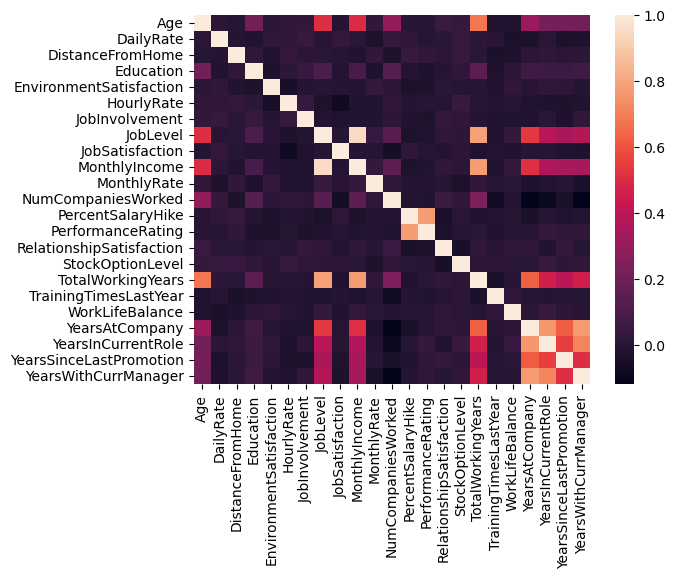

In [608]:
sns.heatmap(corr, annot=False)

In [609]:
df.to_excel('Cleaned_data2.xlsx', index=False)

### Attrition by Job Level

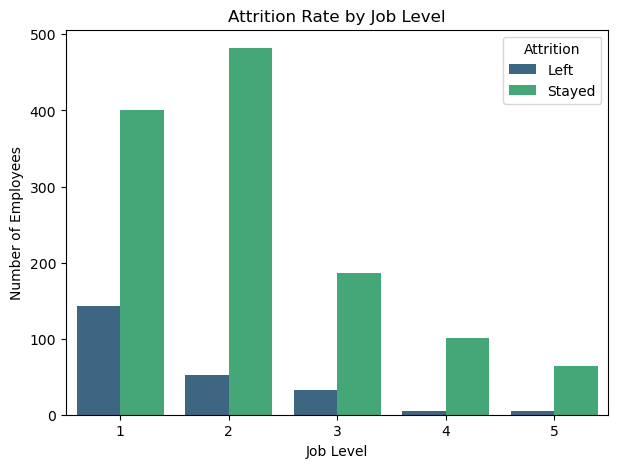

In [610]:
plt.figure(figsize=(7, 5))
sns.countplot(x='JobLevel', hue='Attrition', data=df, palette='viridis')
plt.title('Attrition Rate by Job Level')
plt.xlabel('Job Level')
plt.ylabel('Number of Employees')
plt.legend(title='Attrition', labels=['Left', 'Stayed'])
plt.show()

In [611]:
df['AgeGroup'].dtypes

CategoricalDtype(categories=['18-25', '26-35', '36-45', '46-55', '56+'], ordered=True, categories_dtype=object)

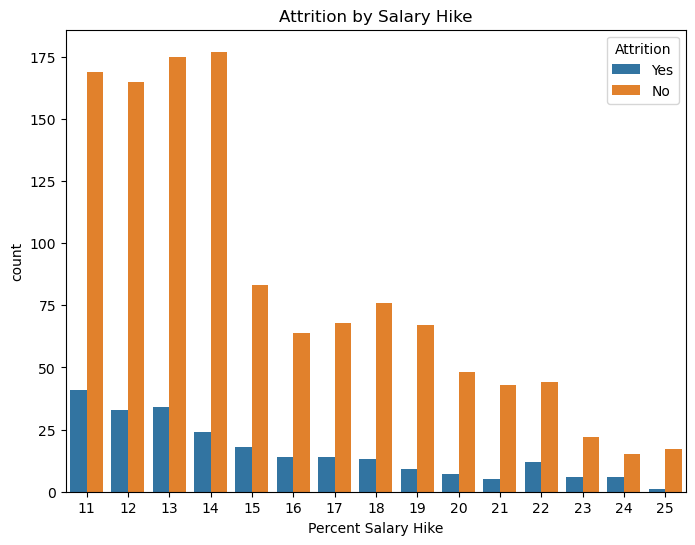

In [612]:
# PercentSalaryHike

plt.figure(figsize=(8,6))
sns.countplot(x='PercentSalaryHike', hue='Attrition', data=df)

plt.xlabel('Percent Salary Hike')
plt.title('Attrition by Salary Hike')
plt.show()


Text(0.5, 0, 'Percent Salary Hike')

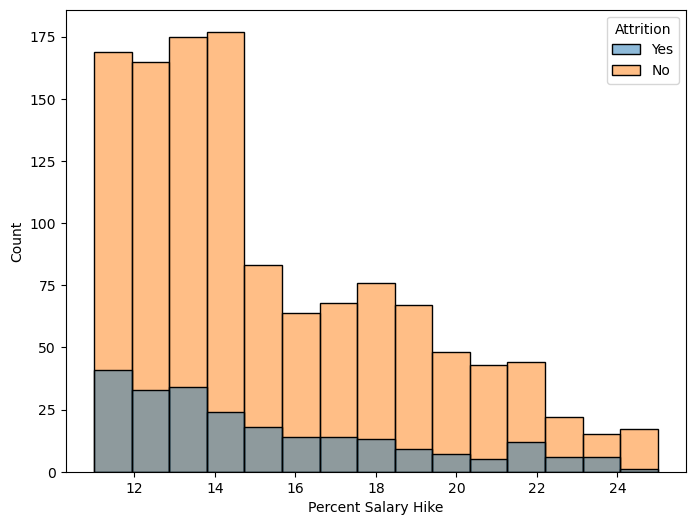

In [616]:
plt.figure(figsize=(8,6))
sns.histplot(x='PercentSalaryHike', hue='Attrition',bins=15, data=df)

plt.xlabel('Percent Salary Hike')

In [618]:
import os
print(os.getcwd())

C:\Users\Panna Chetry
